# Water Potability Analysis

This notebook explores the [Water Potability dataset](https://www.kaggle.com/datasets/adityakadiwal/water-potability) and builds
classification models to predict whether a water sample is **safe to drink (potable)** based on nine
physicochemical measurements (pH, hardness, dissolved solids, chloramines, sulfate, conductivity, organic
carbon, trihalomethanes, and turbidity).

**Workflow:**
1. Load and inspect the data
2. Clean missing values
3. Generate an automated EDA report (`ydata-profiling`)
4. Train and compare five baseline classifiers
5. Evaluate the effect of feature scaling
6. Tune hyperparameters with `GridSearchCV`

> 📄 For a written summary of the methodology, results, and recommendations, see **`REPORT.md`** in this repository.
> A line-by-line list of the bugs found in the original version of this notebook and how they were fixed is in **`README.md`**.


## 1. Imports

Core libraries for data handling, visualization, preprocessing, modeling, and evaluation.

In [ ]:
# Data handling & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

# Automated EDA report
import ydata_profiling

# NOTE ON FIXES (see README.md "Bugs fixed" section for full details):
#   - Removed trailing commas that left `StandardScaler,` and `Kfold,` as dangling
#     imports -> this raised a SyntaxError and prevented the notebook from running at all.
#   - Corrected `Kfold` -> `KFold` (the scikit-learn class name is case-sensitive).
#   - Removed the unused `LinearRegression` import (this is a classification task,
#     the target `Potability` is binary, so a regression model is not appropriate here).
#   - Removed unused `os`, `sys`, `re` imports that were never referenced in the notebook.


## 2. Load the Data

The dataset ships as a single CSV (`water_potability.csv`, 3,276 rows × 10 columns). Place it in the same
folder as this notebook (see `README.md` for the download link) before running the cell below.

In [1]:
data = pd.read_csv("water_potability.csv")
data.head()

NameError: name 'pd' is not defined

## 3. Initial Exploration

Summary statistics for every numeric column.

In [2]:
data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Structural overview of the DataFrame: row/column counts, dtypes, and **non-null counts** — the
non-null counts are the quickest way to spot missing data before doing any cleaning.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


## 4. Data Cleaning

From `data.info()` above, three columns have missing values:

| Column | Missing | % of rows |
|---|---|---|
| `ph` | 491 | ~15.0% |
| `Sulfate` | 781 | ~23.8% |
| `Trihalomethanes` | 162 | ~4.9% |

We also check for duplicate rows before deciding how to handle the missing data.

In [4]:
# NOTE: In a Jupyter cell, only the output of the LAST expression is displayed automatically.
# Wrapping each statement in print() ensures both results are shown rather than only the last one.
print("Missing values per column:")
print(data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

0

No duplicate rows are present. For the missing values, we drop incomplete rows rather than
imputing, since all three affected columns are continuous lab measurements and the missingness pattern
appears unrelated to `Potability` here. This is the simplest approach for a baseline model — see
`REPORT.md` for a discussion of imputation as a possible improvement.

In [ ]:
# Drop any row with at least one missing value.
# This reduces the dataset from 3,276 rows to 2,011 complete rows.
data.dropna(inplace=True)

In [ ]:
# Reset the index so it runs contiguously from 0 after the drop.
# (Equivalent, more idiomatic alternative: data.reset_index(drop=True, inplace=True))
data.index = range(len(data))

## 5. Generate an Automated EDA Report

[`ydata-profiling`](https://github.com/ydataai/ydata-profiling) generates a self-contained HTML report
with distributions, correlations, and warnings (skew, high cardinality, etc.) for every column. This is a
quick way to do exploratory data analysis without writing custom plotting code. **This can take a minute
or two to run** on datasets of this size.

In [ ]:
ydata_profiling.ProfileReport(
    data, title="Water Potability Data Profiling Report", explorative=True
).to_file("water_potability_data_profile.html")

## 6. Prepare Features and Target

Separate the predictors from the binary target column `Potability` (0 = not potable, 1 = potable).

In [ ]:
x = data.drop('Potability', axis=1)
y = data['Potability']

## 7. Train/Test Split

An 80/20 split with a fixed `random_state` for reproducibility. The target is moderately imbalanced
(~39% potable / ~61% not potable), which is worth keeping in mind when interpreting accuracy later —
see `REPORT.md` for why metrics like F1 and ROC AUC matter more than accuracy here.

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1608, 9), (403, 9), (1608,), (403,))

## 8. Define Baseline Models

Five candidate classifiers spanning linear (Logistic Regression), tree-based (Decision Tree, Random
Forest, XGBoost), and kernel-based (SVM) approaches.

> **Reproducibility note:** none of these set a `random_state`, so `RandomForestClassifier`,
> `DecisionTreeClassifier`, `XGBClassifier`, and `SVC` will give slightly different results on every run.
> For exact reproducibility, pass e.g. `random_state=42` to each. This was intentionally left as-is here
> to match the original results discussed in `REPORT.md`; consider adding it if you re-run this notebook.

In [ ]:
# Renamed from the original `def_ault_models` for clarity/readability — purely cosmetic,
# this does not change any results.
default_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "SVM": SVC(probability=True),
}

## 9. Define an Evaluation Function

A reusable helper that prints a classification report, plots a confusion matrix heatmap, and reports four
summary metrics:
- **Accuracy** — overall fraction correct (can be misleading on imbalanced data)
- **F1 score** — harmonic mean of precision and recall for the positive (potable) class
- **ROC AUC** — ability to rank potable samples above non-potable ones across all thresholds
- **Average precision** — area under the precision-recall curve, more informative than ROC AUC under
  class imbalance

In [ ]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]  # Probability of the positive ("potable") class

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Average Precision Score: {avg_precision:.4f}")

## 10. Train & Evaluate on Raw (Unscaled) Features

Fit each baseline model on the untouched features and compare results. Watch for **Logistic Regression**
and **SVM** in particular — both are sensitive to feature scale, and the wide range of raw values across
columns (e.g. `Solids` is in the tens of thousands while `Turbidity` is below 10) tends to hurt them.

Training Logistic Regression...


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating Logistic Regression...
Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       231
           1       1.00      0.01      0.01       172

    accuracy                           0.58       403
   macro avg       0.79      0.50      0.37       403
weighted avg       0.76      0.58      0.42       403

Confusion Matrix:
[[231   0]
 [171   1]]


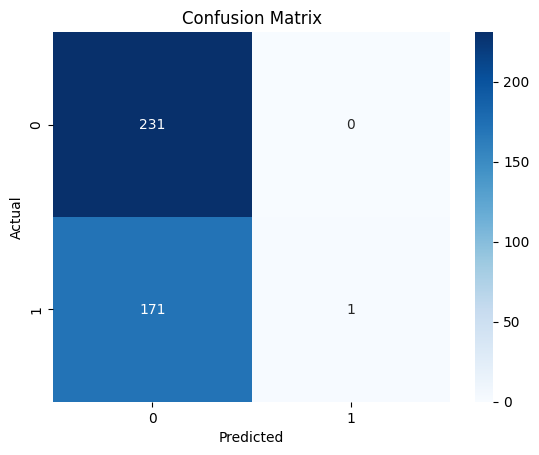

Accuracy: 0.5757
F1 Score: 0.0116
ROC AUC Score: 0.4885
Average Precision Score: 0.4796


Training Random Forest...
Evaluating Random Forest...
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.86      0.75       231
           1       0.68      0.40      0.51       172

    accuracy                           0.67       403
   macro avg       0.67      0.63      0.63       403
weighted avg       0.67      0.67      0.64       403

Confusion Matrix:
[[199  32]
 [103  69]]


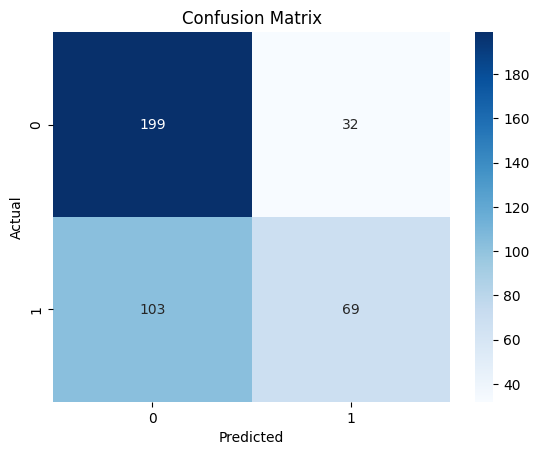

Accuracy: 0.6650
F1 Score: 0.5055
ROC AUC Score: 0.7012
Average Precision Score: 0.6449


Training Decision Tree...
Evaluating Decision Tree...
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.72      0.69       231
           1       0.58      0.52      0.55       172

    accuracy                           0.64       403
   macro avg       0.62      0.62      0.62       403
weighted avg       0.63      0.64      0.63       403

Confusion Matrix:
[[167  64]
 [ 83  89]]


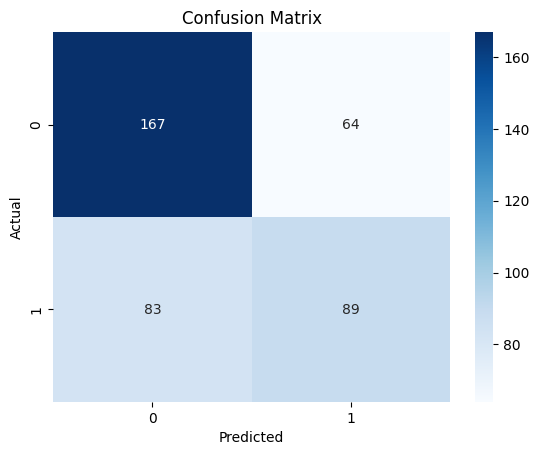

Accuracy: 0.6352
F1 Score: 0.5477
ROC AUC Score: 0.6202
Average Precision Score: 0.5070


Training XGBoost...
Evaluating XGBoost...
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.71       231
           1       0.59      0.48      0.53       172

    accuracy                           0.64       403
   macro avg       0.63      0.62      0.62       403
weighted avg       0.63      0.64      0.63       403

Confusion Matrix:
[[175  56]
 [ 90  82]]


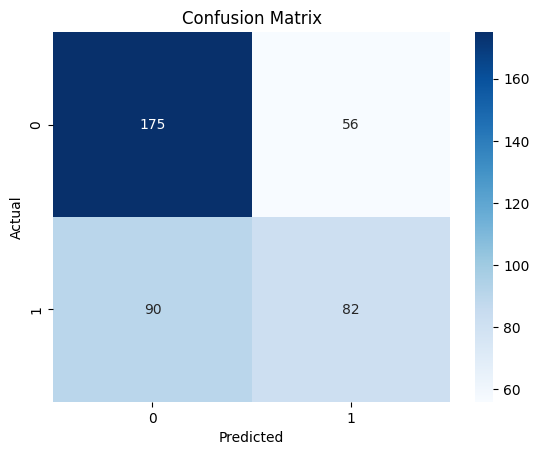

Accuracy: 0.6377
F1 Score: 0.5290
ROC AUC Score: 0.6572
Average Precision Score: 0.6267


Training SVM...
Evaluating SVM...
Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       231
           1       0.00      0.00      0.00       172

    accuracy                           0.57       403
   macro avg       0.29      0.50      0.36       403
weighted avg       0.33      0.57      0.42       403

Confusion Matrix:
[[231   0]
 [172   0]]


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

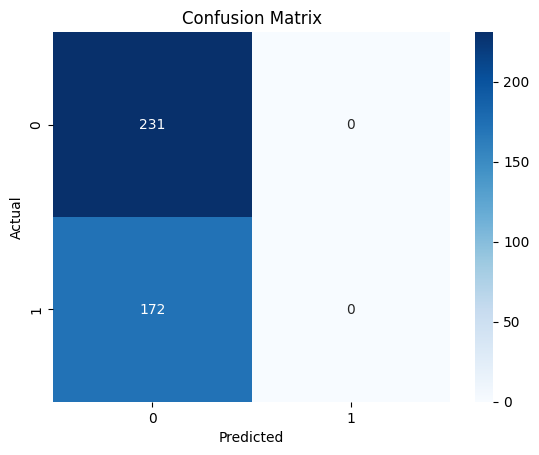

Accuracy: 0.5732
F1 Score: 0.0000
ROC AUC Score: 0.4988
Average Precision Score: 0.4404




In [6]:
# Train and evaluate each model
for name, model in default_models.items():
    print(f"Training {name}...")
    model.fit(x_train, y_train)
    print(f"Evaluating {name}...")
    evaluate_model(model, x_test, y_test)
    print("\n" + "="*50 + "\n")

## 11. Feature Scaling

`StandardScaler` rescales every feature to zero mean / unit variance. This matters for **distance- and
gradient-based** models (SVM, Logistic Regression) but has little to no effect on **tree-based** models
(Decision Tree, Random Forest, XGBoost), since trees split on feature thresholds regardless of scale.

The scaler is fit on the training data only and then applied to the test data, to avoid leaking test-set
statistics into training.

In [7]:
standard_scaler = StandardScaler()
standard_scaler.fit(x_train)
x_train_scaled = standard_scaler.transform(x_train)
x_test_scaled = standard_scaler.transform(x_test)
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_train_scaled_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,1.821142,0.376545,-0.272679,0.555382,0.175832,0.683571,-0.908293,1.205283,0.110310
1,1.086930,0.587054,-0.936540,0.265743,-0.246111,-0.719724,1.403092,-0.734609,-0.241957
2,0.647668,-2.169517,0.224182,1.036700,-0.369649,-0.358351,0.290141,-0.240604,0.402532
3,1.702218,-0.894890,-0.976887,0.068932,1.260315,-0.712640,-0.614070,0.123821,-1.790104
4,-1.086877,0.473608,2.698489,-0.298800,-1.287291,0.722002,1.636454,0.251238,0.351501
...,...,...,...,...,...,...,...,...,...
1603,0.576664,-1.366438,0.380702,-0.012832,0.468076,1.236450,0.447023,-0.889851,-0.736047
1604,-0.340343,-0.396710,-0.899813,0.794900,0.970752,0.838607,-0.823269,-0.490736,-0.888085
1605,0.354766,0.265728,-1.585091,-0.701387,2.064830,-1.432773,-0.485723,0.047438,0.355475
1606,0.534867,0.445207,-0.712021,-0.138012,-0.316572,0.262234,1.173974,3.588228,-1.424166


### Train & Evaluate on Scaled Features

Re-run the same five models on the standardized data and compare against the raw-feature results above.

Training Logistic Regression...
Evaluating Logistic Regression...
Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       231
           1       0.00      0.00      0.00       172

    accuracy                           0.57       403
   macro avg       0.29      0.50      0.36       403
weighted avg       0.33      0.57      0.42       403

Confusion Matrix:
[[230   1]
 [172   0]]


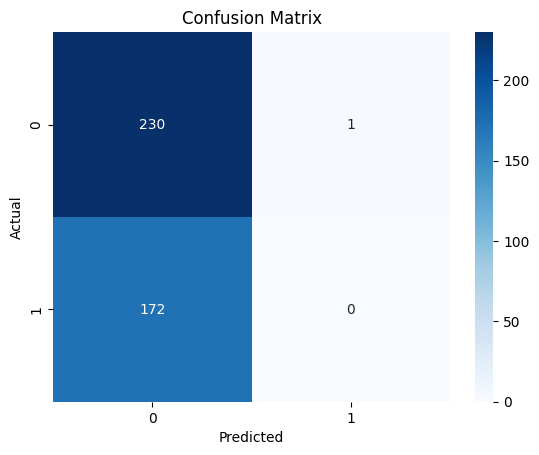

Accuracy: 0.5707
F1 Score: 0.0000
ROC AUC Score: 0.4647
Average Precision Score: 0.4273


Training Random Forest...
Evaluating Random Forest...
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.83      0.73       231
           1       0.65      0.42      0.51       172

    accuracy                           0.66       403
   macro avg       0.65      0.62      0.62       403
weighted avg       0.65      0.66      0.64       403

Confusion Matrix:
[[192  39]
 [100  72]]


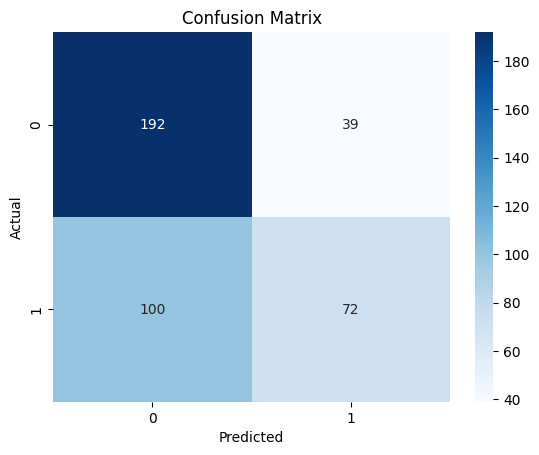

Accuracy: 0.6551
F1 Score: 0.5088
ROC AUC Score: 0.6924
Average Precision Score: 0.6608


Training Decision Tree...
Evaluating Decision Tree...
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.68       231
           1       0.57      0.52      0.55       172

    accuracy                           0.63       403
   macro avg       0.62      0.61      0.62       403
weighted avg       0.62      0.63      0.63       403

Confusion Matrix:
[[163  68]
 [ 82  90]]


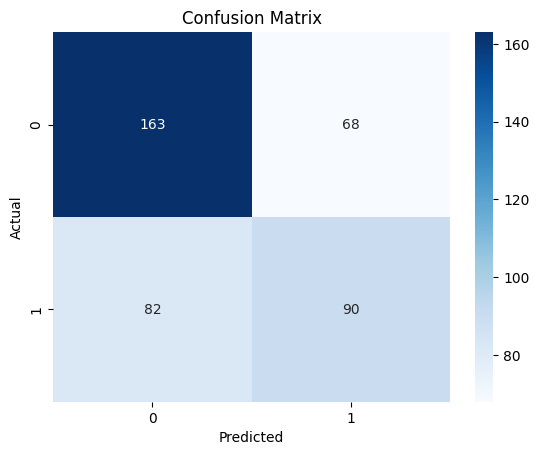

Accuracy: 0.6278
F1 Score: 0.5455
ROC AUC Score: 0.6144
Average Precision Score: 0.5015


Training XGBoost...
Evaluating XGBoost...
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.71       231
           1       0.59      0.48      0.53       172

    accuracy                           0.64       403
   macro avg       0.63      0.62      0.62       403
weighted avg       0.63      0.64      0.63       403

Confusion Matrix:
[[175  56]
 [ 90  82]]


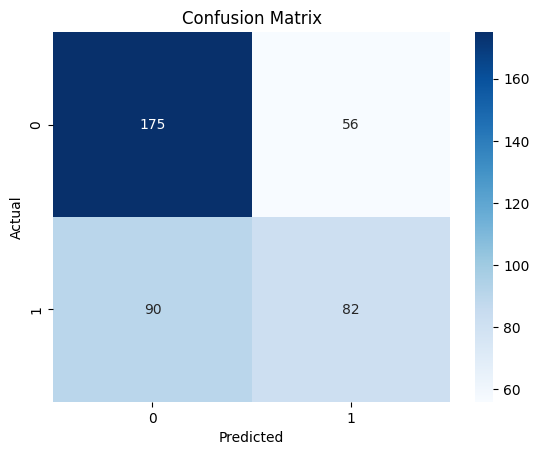

Accuracy: 0.6377
F1 Score: 0.5290
ROC AUC Score: 0.6572
Average Precision Score: 0.6267


Training SVM...
Evaluating SVM...
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       231
           1       0.73      0.37      0.49       172

    accuracy                           0.67       403
   macro avg       0.69      0.63      0.63       403
weighted avg       0.69      0.67      0.64       403

Confusion Matrix:
[[207  24]
 [108  64]]


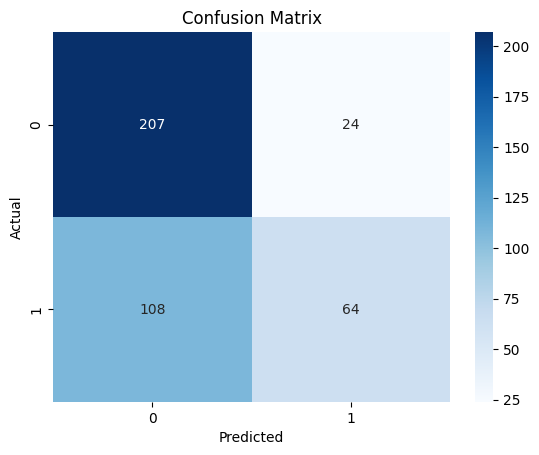

Accuracy: 0.6725
F1 Score: 0.4923
ROC AUC Score: 0.7248
Average Precision Score: 0.6563




In [8]:
# Train and evaluate each model
for name, model in default_models.items():
    print(f"Training {name}...")
    model.fit(x_train_scaled, y_train)
    print(f"Evaluating {name}...")
    evaluate_model(model, x_test_scaled, y_test)
    print("\n" + "="*50 + "\n")

**Takeaway:** scaling makes a large difference for **SVM** (ROC AUC 0.499 → 0.725, becoming the
best single model in this notebook) and has a smaller but real effect on Logistic Regression. Random
Forest, Decision Tree, and XGBoost are essentially unchanged, as expected for tree-based models. See the
comparison chart in `REPORT.md` for a visual summary.

## 12. Hyperparameter Tuning

`GridSearchCV` exhaustively searches a parameter grid with 5-fold cross-validation and refits the
best-scoring combination on the full training set. We tune Logistic Regression and Random Forest here
(on the scaled features), and XGBoost separately below.

In [9]:
gcv = GridSearchCV(estimator=LogisticRegression(), param_grid={"C": [0.01, 0.1, 1, 10, 100]}, cv=5)
gcv.fit(x_train_scaled, y_train)

0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       231
           1       0.00      0.00      0.00       172

    accuracy                           0.57       403
   macro avg       0.29      0.50      0.36       403
weighted avg       0.33      0.57      0.42       403

Confusion Matrix:
[[230   1]
 [172   0]]


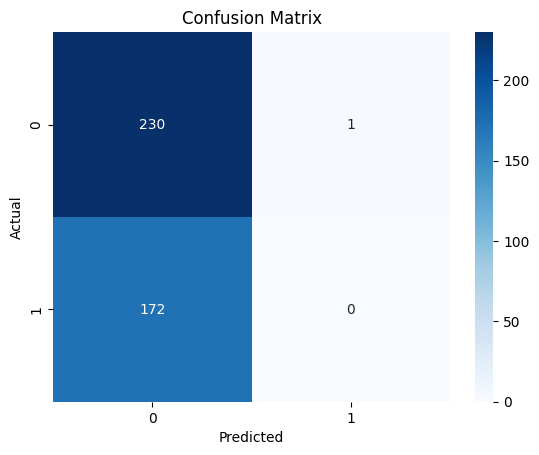

Accuracy: 0.5707
F1 Score: 0.0000
ROC AUC Score: 0.4647
Average Precision Score: 0.4273


In [10]:
evaluate_model(gcv.best_estimator_, x_test_scaled, y_test)

Tuning the regularization strength `C` does not rescue Logistic Regression here — it still predicts
almost every sample as the majority ("not potable") class. This points to a genuine **linear
separability** limitation rather than a tuning problem: see `REPORT.md` for discussion.

Evaluating Random Forest...
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.94      0.75       231
           1       0.75      0.26      0.39       172

    accuracy                           0.65       403
   macro avg       0.69      0.60      0.57       403
weighted avg       0.68      0.65      0.60       403

Confusion Matrix:
[[216  15]
 [127  45]]


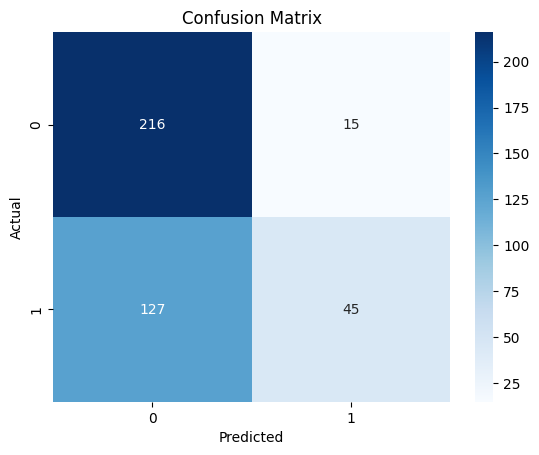

Accuracy: 0.6476
F1 Score: 0.3879
ROC AUC Score: 0.6925
Average Precision Score: 0.6500




In [11]:
gcv_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid={"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7]},
    cv=5,
)
gcv_rf.fit(x_train_scaled, y_train)

# FIX: the original code referenced a leftover `name` variable from the training loop above,
# which happened to still hold "Random Forest" by coincidence of execution order rather than by
# design. Hardcoding the label here makes the output correct regardless of what was run before it.
print("Evaluating Random Forest...")
evaluate_model(gcv_rf.best_estimator_, x_test_scaled, y_test)
print("\n" + "="*50 + "\n")

Note the tuned Random Forest actually scores **lower** on F1 (0.39 vs. 0.51 for the untuned
baseline) despite a comparable ROC AUC. The grid restricts `max_depth` to at most 7, which favors overall
separability (AUC) over recall on the minority "potable" class at the default 0.5 decision threshold. This
is a good illustration of why the optimization target (here, default `GridSearchCV` accuracy scoring)
should match the metric you actually care about — see `REPORT.md` for more on this trade-off.

## 13. Tuning XGBoost (optimizing ROC AUC directly)

For XGBoost we search a wider grid and explicitly set `scoring="roc_auc"`, which is more appropriate than
the default accuracy scoring given the class imbalance. This is run on the raw (unscaled) features —
fine for a tree-based model, which is invariant to monotonic feature scaling.

In [12]:
def result_row(label, acc, auc):
    print(f"  {label:<35}  Acc={acc:.4f}  AUC={auc:.4f}")

grid_params = {
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.05, 0.1, 0.2],
    "n_estimators":    [100, 200],
    "subsample":       [0.8, 1.0],
}

grid_model = xgb.XGBClassifier(
    random_state=42, eval_metric="logloss", verbosity=0
)

grid_search = GridSearchCV(
    grid_model, grid_params,
    cv=5, scoring="roc_auc",
    n_jobs=-1, verbose=0
)
grid_search.fit(x_train, y_train)

best_grid = grid_search.best_estimator_
y_pred_grid = best_grid.predict(x_test)
y_prob_grid = best_grid.predict_proba(x_test)[:, 1]
acc_grid = accuracy_score(y_test, y_pred_grid)
auc_grid = roc_auc_score(y_test, y_prob_grid)
confusion_matrix_grid = confusion_matrix(y_test, y_pred_grid)

print(f"  Best params : {grid_search.best_params_}")
result_row("GridSearchCV", acc_grid, auc_grid)
print("Confusion Matrix:")
print(confusion_matrix_grid)

  Best params : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
  GridSearchCV                         Acc=0.6625  AUC=0.6854
Confusion Matrix:
[[186  45]
 [ 91  81]]


## 14. Summary

| Model | Features | Accuracy | F1 | ROC AUC |
|---|---|---|---|---|
| Logistic Regression | raw | 0.576 | 0.012 | 0.489 |
| Random Forest | raw | 0.665 | 0.506 | **0.701** |
| Decision Tree | raw | 0.635 | **0.548** | 0.620 |
| XGBoost | raw | 0.638 | 0.529 | 0.657 |
| SVM | raw | 0.573 | 0.000 | 0.499 |
| Logistic Regression | scaled | 0.571 | 0.000 | 0.465 |
| Random Forest | scaled | 0.655 | 0.509 | 0.692 |
| Decision Tree | scaled | 0.628 | 0.546 | 0.614 |
| XGBoost | scaled | 0.638 | 0.529 | 0.657 |
| **SVM** | **scaled** | **0.673** | 0.492 | **0.725** |
| XGBoost (tuned, `roc_auc`) | raw | 0.663 | – | 0.685 |

**Best overall model:** scaled **SVM** by ROC AUC (0.725); tuned **XGBoost** is close behind (0.685) and
arguably more reliable since cross-validation was used to select it. **Decision Tree** gets the best raw
F1 score, but its accuracy and AUC trail the ensemble methods.

No model here is strong enough for production use on its own — see `REPORT.md` for a full discussion of
limitations (class imbalance, missing-data handling, lack of feature engineering) and recommended next
steps (resampling, threshold tuning, stacking/ensembling, more exhaustive tuning for SVM/Decision Tree).
